🔢 Categorical columns encoded successfully!
✅ Optimized Random Forest model loaded successfully!


/var/folders/mn/c4n_vz_92_s8kpf1y69hj4fw0000gn/T/ipykernel_76988/3062204083.py:84: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/aarush/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


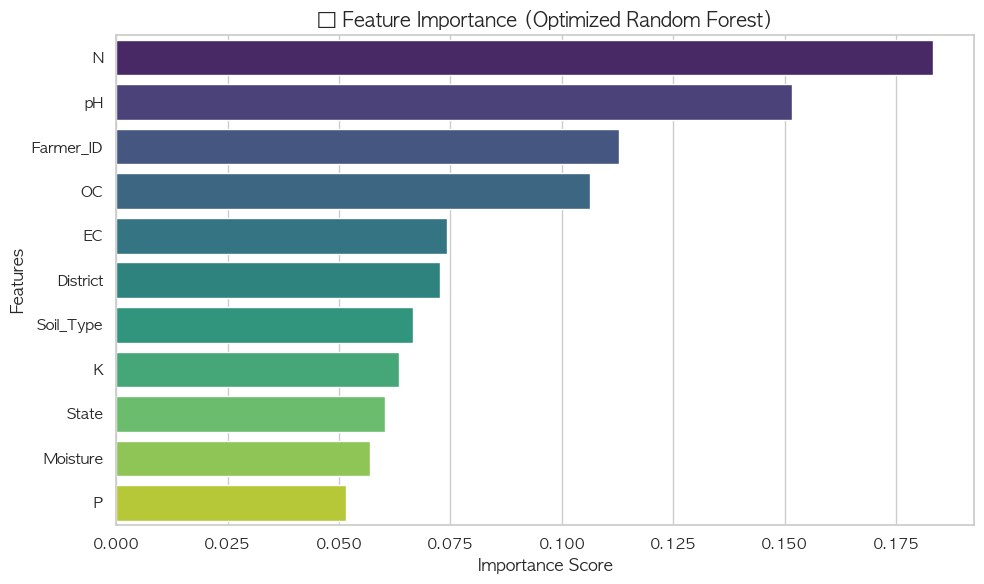

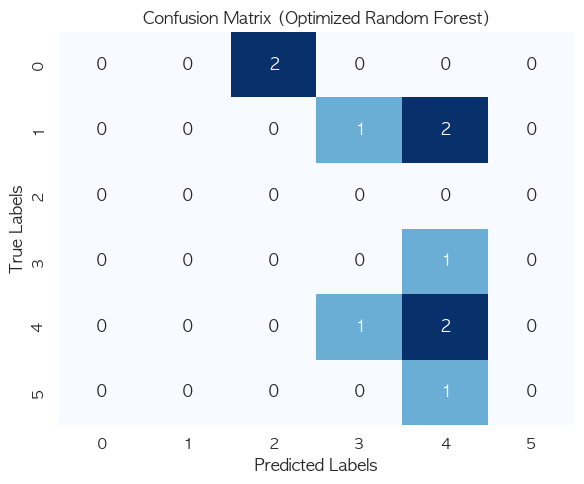

✅ Optimized Random Forest Accuracy: 0.20

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.33      0.67      0.44         3
           5       0.00      0.00      0.00         1

    accuracy                           0.20        10
   macro avg       0.06      0.11      0.07        10
weighted avg       0.10      0.20      0.13        10



In [4]:
# 04c_model_visualization.ipynb
# Member 3 — Visualization & Evaluation of Optimized Random Forest

# ==============================
# 📦 Import libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# ==============================
# 📂 Load dataset
# ==============================
df = pd.read_csv('../data/processed/soil_reduced_features.csv')

# ==============================
# 🔢 Encode categorical columns (same as training)
# ==============================
categorical_cols = ['State', 'District', 'Farmer_ID', 'Soil_Type']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("🔢 Categorical columns encoded successfully!")

# ==============================
# 🎯 Encode target column
# ==============================
target_le = LabelEncoder()
df['Crop_Suitability'] = target_le.fit_transform(df['Crop_Suitability'])

# ==============================
# ✂️ Split features and labels
# ==============================
X = df.drop(columns=['Crop_Suitability'])
y = df['Crop_Suitability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 🌲 Load optimized Random Forest model
# ==============================
best_rf = joblib.load('../models/optimized_random_forest.joblib')
print("✅ Optimized Random Forest model loaded successfully!")

# ==============================
# 🧠 Make predictions
# ==============================
y_pred = best_rf.predict(X_test)

# ==============================
# 📊 Feature Importance Visualization
# ==============================
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# Optional fix for emoji font warning
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'AppleGothic'  # macOS-safe

plt.figure(figsize=(10,6))
sns.barplot(
    x=feature_importances.values,
    y=feature_importances.index,
    hue=feature_importances.index,
    palette="viridis",
    legend=False
)
plt.title("🌾 Feature Importance (Optimized Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# ==============================
# 🔍 Confusion Matrix Visualization
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (Optimized Random Forest)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

# ==============================
# 📈 Performance Metrics
# ==============================
acc = accuracy_score(y_test, y_pred)
print(f"✅ Optimized Random Forest Accuracy: {acc:.2f}\n")

print("📋 Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
